In [2]:
import os
import torch
from timm import create_model
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from collections import defaultdict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import json

c:\Users\HP\studia\trzeci rok\semestr6\Warsztaty Badawcze\proekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In this task, we focus on evaluating the representational quality of different layers in a pretrained Vision Transformer model, specifically the DINO self-supervised model. We extract features from each transformer block and train lightweight linear classifiers (linear probes). This procedure allows us to measure how linearly separable the learned features are at each depth of the network. The primary goal is to understand which layers encode the most useful semantic information for classification tasks. This analysis serves as a foundation for subsequent investigations, such as layer-skipping strategies or representational redundancy detection, aiming to optimize inference without significantly sacrificing model performance.

In [3]:
train_path = "C:\\Users\\HP\\Downloads\\archive (15)\\train.X1"
val_path = "C:\\Users\\HP\\Downloads\\archive (15)\\val.X"

train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=val_transform)

selected_classes = train_dataset.classes[:5]
print("Selected classes:", selected_classes)

class_indices = [train_dataset.class_to_idx[cls] for cls in selected_classes]

def get_class_subset(dataset, class_indices):
    selected = [i for i, (_, label) in enumerate(dataset.samples) if label in class_indices]
    return Subset(dataset, selected)

train_subset = get_class_subset(train_dataset, class_indices)
val_subset = get_class_subset(val_dataset, class_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

def get_labels_from_loader(loader):
    labels = []
    for _, batch_labels in loader:
        labels.extend(batch_labels.numpy())
    return np.array(labels)

y_train = get_labels_from_loader(train_loader)
y_val = get_labels_from_loader(val_loader)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}


Selected classes: ['n01440764', 'n01484850', 'n01494475', 'n01531178', 'n01632777']


In [4]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Using cache found in C:\Users\HP/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [5]:
@torch.no_grad()
def collect_logits_from_batches(model, dataloader, max_batches=None):
    all_logits = []

    def hook_fn(module, input, output):
        features.append(output)

    hooks = []
    features = []

    for blk in model.blocks:
        hooks.append(blk.register_forward_hook(hook_fn))

    for i, (images, _) in enumerate(dataloader):
        if max_batches and i >= max_batches:
            break
        features.clear()
        images = images.to(device)
        _ = model(images)
        layer_cls_outputs = [f[:, 0].detach().cpu() for f in features]
        all_logits.append(layer_cls_outputs)

    for h in hooks:
        h.remove()

    return all_logits


In [6]:
print("Collecting train logits...")
train_logits = collect_logits_from_batches(model, train_loader)
print("Collecting val logits...")
val_logits = collect_logits_from_batches(model, val_loader)

In [7]:
num_layers = len(train_logits[0])
train_representations = []
val_representations = []

for i in range(num_layers):
    train_layer = [batch[i] for batch in train_logits]
    val_layer = [batch[i] for batch in val_logits]
    train_representations.append(torch.cat(train_layer, dim=0))
    val_representations.append(torch.cat(val_layer, dim=0))

In [8]:

os.makedirs("linear_probes", exist_ok=True)
metrics_dict = {}

for layer in range(num_layers):
    print(f"\nTraining classifier on layer {layer}...")

    X_train = train_representations[layer].numpy()
    X_val = val_representations[layer].numpy()

    clf = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', class_weight=class_weight_dict)
    clf.fit(X_train, y_train)

    y_val_pred = clf.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
    rec = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

    print(f"→ Val Accuracy (layer {layer}): {acc:.4f}")
    print(f"→ Val Precision (layer {layer}): {prec:.4f}")
    print(f"→ Val Recall (layer {layer}): {rec:.4f}")
    print(f"→ Val F1-score (layer {layer}): {f1:.4f}")

    metrics_dict[layer] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }


    joblib.dump(clf, f"linear_probes/linear_probe_layer{layer}.joblib")
    with open("metrics_dict.json", "w") as f:
        json.dump(metrics_dict, f, indent=4)



Training classifier on layer 0...


c:\Users\HP\studia\trzeci rok\semestr6\Warsztaty Badawcze\proekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


→ Val Accuracy (layer 0): 0.2640
→ Val Precision (layer 0): 0.2766
→ Val Recall (layer 0): 0.2640
→ Val F1-score (layer 0): 0.2447

Training classifier on layer 1...


c:\Users\HP\studia\trzeci rok\semestr6\Warsztaty Badawcze\proekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


→ Val Accuracy (layer 1): 0.2120
→ Val Precision (layer 1): 0.2294
→ Val Recall (layer 1): 0.2120
→ Val F1-score (layer 1): 0.1894

Training classifier on layer 2...


...

→ Val Accuracy (layer 9): 0.1360
→ Val Precision (layer 9): 0.1388
→ Val Recall (layer 9): 0.1360
→ Val F1-score (layer 9): 0.1349

Training classifier on layer 10...


c:\Users\HP\studia\trzeci rok\semestr6\Warsztaty Badawcze\proekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


→ Val Accuracy (layer 10): 0.1520
→ Val Precision (layer 10): 0.1507
→ Val Recall (layer 10): 0.1520
→ Val F1-score (layer 10): 0.1504

Training classifier on layer 11...


c:\Users\HP\studia\trzeci rok\semestr6\Warsztaty Badawcze\proekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


→ Val Accuracy (layer 11): 0.1480
→ Val Precision (layer 11): 0.1518
→ Val Recall (layer 11): 0.1480
→ Val F1-score (layer 11): 0.1483


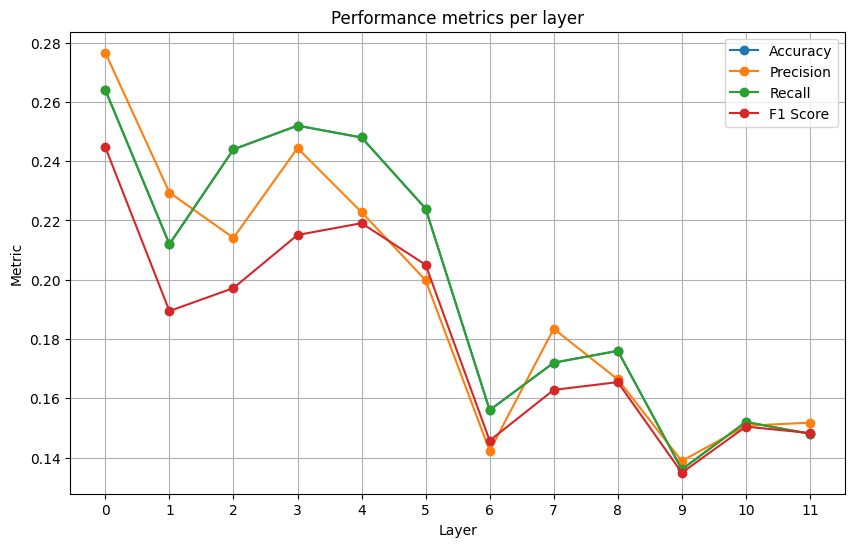

In [9]:
import matplotlib.pyplot as plt

layers = list(metrics_dict.keys())
accuracy = [metrics_dict[l]['accuracy'] for l in layers]
precision = [metrics_dict[l]['precision'] for l in layers]
recall = [metrics_dict[l]['recall'] for l in layers]
f1_score = [metrics_dict[l]['f1_score'] for l in layers]

plt.figure(figsize=(10,6))

plt.plot(layers, accuracy, label='Accuracy', marker='o')
plt.plot(layers, precision, label='Precision', marker='o')
plt.plot(layers, recall, label='Recall', marker='o')
plt.plot(layers, f1_score, label='F1 Score', marker='o')

plt.xlabel('Layer')
plt.ylabel('Metric')
plt.title('Performance metrics per layer')
plt.legend()
plt.grid(True)
plt.xticks(layers)
plt.show()


-----------------------------------------------------------------------------------------------------------------------    koniec ----------------------------------

In [10]:
import torch

@torch.no_grad()
def forward_cls_through_blocks(model, cls_input, start_layer, end_layer):
    """
    Przepuszcza CLS token przez kolejne bloki transformerowe modelu ViT.
    Zakładamy, że wejściem jest CLS token + reszta tokenów (tu reszta to padding).
    """
    x = cls_input
    for i in range(start_layer, end_layer + 1):
        x = model.blocks[i](x)
    return x


In [ ]:
from sklearn.metrics import accuracy_score
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

skip_metrics = {}

for l in range(num_layers - 2): 
    print(f"\nTestujemy SKIP z warstwy {l} do {l+2}...")

    clf = joblib.load(f"linear_probes/linear_probe_layer{l}.joblib")

    val_cls = torch.tensor(val_representations[l]).to(device)

    dummy_patches = torch.zeros(val_cls.size(0), 1, val_cls.size(1), device=device) 
    x = torch.cat([val_cls.unsqueeze(1), dummy_patches], dim=1)

    x = forward_cls_through_blocks(model, x, l + 1, l + 2)

    x_cls = x[:, 0].cpu().numpy()

    y_val_pred = clf.predict(x_cls)

    acc = accuracy_score(y_val, y_val_pred)
    print(f"→ Accuracy po skipnięciu l+1 i l+2: {acc:.4f}")

    skip_metrics[l] = acc



Testujemy SKIP z warstwy 0 do 2...
→ Accuracy po skipnięciu l+1 i l+2: 0.2000

Testujemy SKIP z warstwy 1 do 3...
→ Accuracy po skipnięciu l+1 i l+2: 0.2280

Testujemy SKIP z warstwy 2 do 4...
→ Accuracy po skipnięciu l+1 i l+2: 0.2000

Testujemy SKIP z warstwy 3 do 5...
→ Accuracy po skipnięciu l+1 i l+2: 0.1840

Testujemy SKIP z warstwy 4 do 6...
→ Accuracy po skipnięciu l+1 i l+2: 0.1960

Testujemy SKIP z warstwy 5 do 7...
→ Accuracy po skipnięciu l+1 i l+2: 0.1840

Testujemy SKIP z warstwy 6 do 8...
→ Accuracy po skipnięciu l+1 i l+2: 0.1800

Testujemy SKIP z warstwy 7 do 9...
→ Accuracy po skipnięciu l+1 i l+2: 0.1920

Testujemy SKIP z warstwy 8 do 10...


C:\Users\HP\AppData\Local\Temp\ipykernel_2428\804451515.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_cls = torch.tensor(val_representations[l]).to(device)
C:\Users\HP\AppData\Local\Temp\ipykernel_2428\804451515.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_cls = torch.tensor(val_representations[l]).to(device)
C:\Users\HP\AppData\Local\Temp\ipykernel_2428\804451515.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_cls = torch.tensor(val_representations[l]).to(device)
C:\Users\HP\AppData\Local\Temp\ipykernel_24

→ Accuracy po skipnięciu l+1 i l+2: 0.2000

Testujemy SKIP z warstwy 9 do 11...
→ Accuracy po skipnięciu l+1 i l+2: 0.2160


C:\Users\HP\AppData\Local\Temp\ipykernel_2428\804451515.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_cls = torch.tensor(val_representations[l]).to(device)


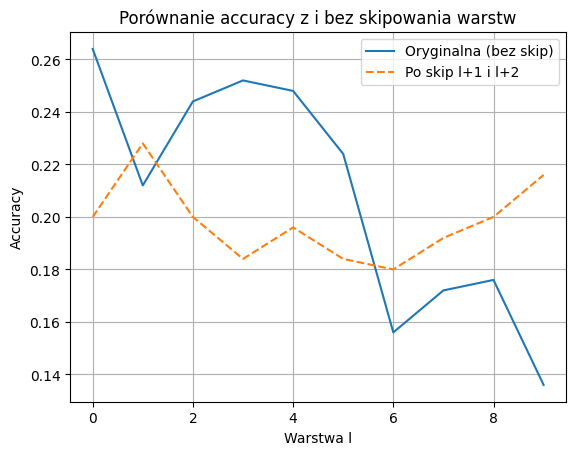

In [12]:
import matplotlib.pyplot as plt

layers = list(skip_metrics.keys())
original_acc = [metrics_dict[l]['accuracy'] for l in layers]
skipped_acc = [skip_metrics[l] for l in layers]

plt.plot(layers, original_acc, label='Oryginalna (bez skip)')
plt.plot(layers, skipped_acc, label='Po skip l+1 i l+2', linestyle='--')
plt.xlabel('Warstwa l')
plt.ylabel('Accuracy')
plt.title('Porównanie accuracy z i bez skipowania warstw')
plt.legend()
plt.grid(True)
plt.show()
